In [2]:
from open_tpose import tposeOct2012_hourly
import xgcm
import numpy as np
import warnings
import matplotlib.pyplot as plt
import sys
sys.path.append('../../')
from matplotlib.colors import TwoSlopeNorm, LogNorm
import sys
warnings.filterwarnings("ignore")
import cmocean.cm as cmo

plt.rcParams['font.size'] = 17

filename_heat = 'diag_heat_budget'
filename_kpp = 'diag_kpp'
filename_mom_u = 'diag_mom_u'
filename_state = 'diag_state'
filename_surf = 'diag_surf'


zMin = -250
zMax = 0

lon = 220.0
latMin = -0.1
latMax = 0.1

print('lon: ' + str(lon))
print('lat min: ' + str(latMin))
print('lat max: ' + str(latMax))

ds = tposeOct2012_hourly([filename_surf,filename_state,filename_kpp,filename_mom_u,filename_heat],ref_date='2012-10-01')
ds['XC'] = ds.XC.astype(float)
ds['YC'] = ds.YC.astype(float)
ds['Z'] = ds.Z.astype(float)
ds['XG'] = ds.XG.astype(float)
ds['YG'] = ds.YG.astype(float)
ds['Zl'] = ds.Zl.astype(float)

lon: 220.0
lat min: -0.1
lat max: 0.1


In [3]:
grid = xgcm.Grid(ds, periodic=['X','Y'])

vol = (ds.rAw*ds.hFacW*ds.drF)
ds['KPP_momU'] = grid.diff(ds.VISrI_Um,'Z',boundary='fill',fill_value=0)/vol
ds['KPP_momU'] = ds.KPP_momU.where(ds.hFacW.values > 0,0) # set any nan fluxes to 0

KPP_heat = grid.diff(ds.KPPg_TH,'Z',boundary='fill',fill_value=0)/(ds.hFacC * ds.rA * ds.drF)

uvel_l = grid.interp(ds.UVEL,'Z')
dUdz = grid.diff(uvel_l,'Z')/(-1*ds.drF)
dUdz_XC = grid.interp(dUdz,'X') # this will need to be on YC, XC, in order to be used with N2 to get Ri

vvel_l = grid.interp(ds.VVEL,'Z')
dVdz = grid.diff(vvel_l,'Z')/(-1*ds.drF)
dVdz_YC = grid.interp(dVdz,'Y') # this will need to be on YC, XC, in order to be used with N2 to get Ri

startDay = 12 + (24*8)
# S = dUdz_XC.isel(time=slice(startDay,-1)).sel(YC=slice(-0.1,0.1),Z=slice(zMax,zMin)).sel(XC=[220.0],method='nearest') + dVdz_YC.isel(time=slice(startDay,-1)).sel(YC=slice(-0.1,0.1),Z=slice(zMax,zMin)).sel(XC=[220.0],method='nearest')
S2 = dUdz_XC.isel(time=slice(startDay,-1)).sel(YC=slice(-0.1,0.1),Z=slice(zMax,zMin)).sel(XC=[220.0],method='nearest')**2 + dVdz_YC.isel(time=slice(startDay,-1)).sel(YC=slice(-0.1,0.1),Z=slice(zMax,zMin)).sel(XC=[220.0],method='nearest')**2
S2 = S2.mean(dim='YC')

shear = np.sqrt(S2).squeeze().load()

# (kg/m4)*(m/s2) * (m3/kg) -> 1/s2
N2 = grid.interp(ds.DRHODR,'Z') * (-9.8/1035) # this is the reference rho that ariane used for TPOSE6, check that this is still what we want (used for closing budgets)
N2 = N2.isel(time=slice(startDay,-1)).sel(YC=slice(-0.1,0.1),Z=slice(zMax,zMin)).sel(XC=[220.0],method='nearest') # take the mean over the latitudes and depths
# N = (np.sqrt(N2) * 3600)/(2*np.pi) # this gives 1/hrs (assumed radians) need a /(2*np.pi) factor, convert  to cph
N2 = N2.mean(dim='YC')

Ri = (N2/S2).squeeze().load()

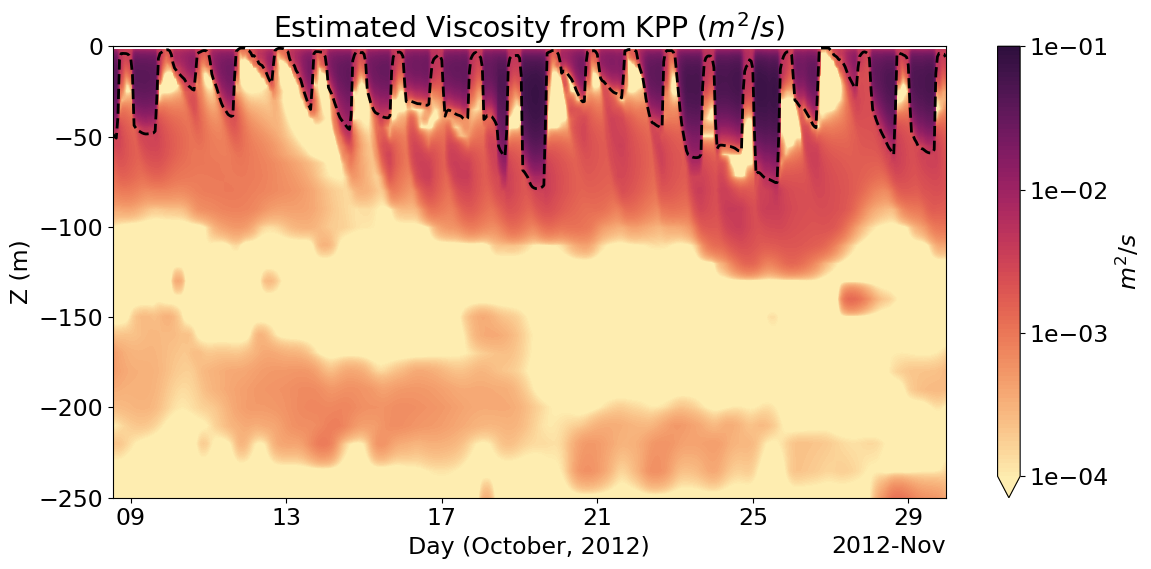

In [4]:
from matplotlib.ticker import LogFormatter
startDay = 12 + (24*8)

fig, ax = plt.subplots(figsize=(12,6),nrows=1)
plot_hbl = -1*ds.KPPhbl.isel(time=slice(startDay,-1)).sel(YC=slice(-0.1,0.1)).sel(XC=[220.0],method='nearest').mean(dim='YC').squeeze().load()

levels = np.logspace(-4,-1,100)
plot_visc = ds.KPPviscA.isel(time=slice(startDay,-1)).sel(YC=slice(-0.1,0.1),Zl=slice(zMax,zMin)).sel(XC=[220.0],method='nearest').mean(dim='YC').squeeze().load()
plot_visc.plot.contourf(ax=ax,x='time',y='Zl',levels=levels,norm=LogNorm(vmin=1e-4,vmax=1e-1),cmap=cmo.matter,cbar_kwargs={'label':'$m^2/s$',"format": LogFormatter(),'ticks':[1e-4,1e-3,1e-2,1e-1]})
plot_hbl.plot(ax=ax,x='time',label='KPP BL',linewidth=2.0,color='k',linestyle='--')
ax.set_ylabel('Z (m)')
ax.set_xlabel('Day (October, 2012)')
ax.set_title('Estimated Viscosity from KPP ($m^2/s$)')
plt.tight_layout()

In [5]:
threshold = 0.5
masked_depths = Ri.sel(Z=slice(-25,-130))['Z'].where(Ri < threshold)

# shallowest = smallest depth value in absolute terms (closest to surface)
shallowest = masked_depths.max(dim='Z')

# deepest = largest depth value in absolute terms (farthest below surface)
deepest = masked_depths.min(dim='Z')

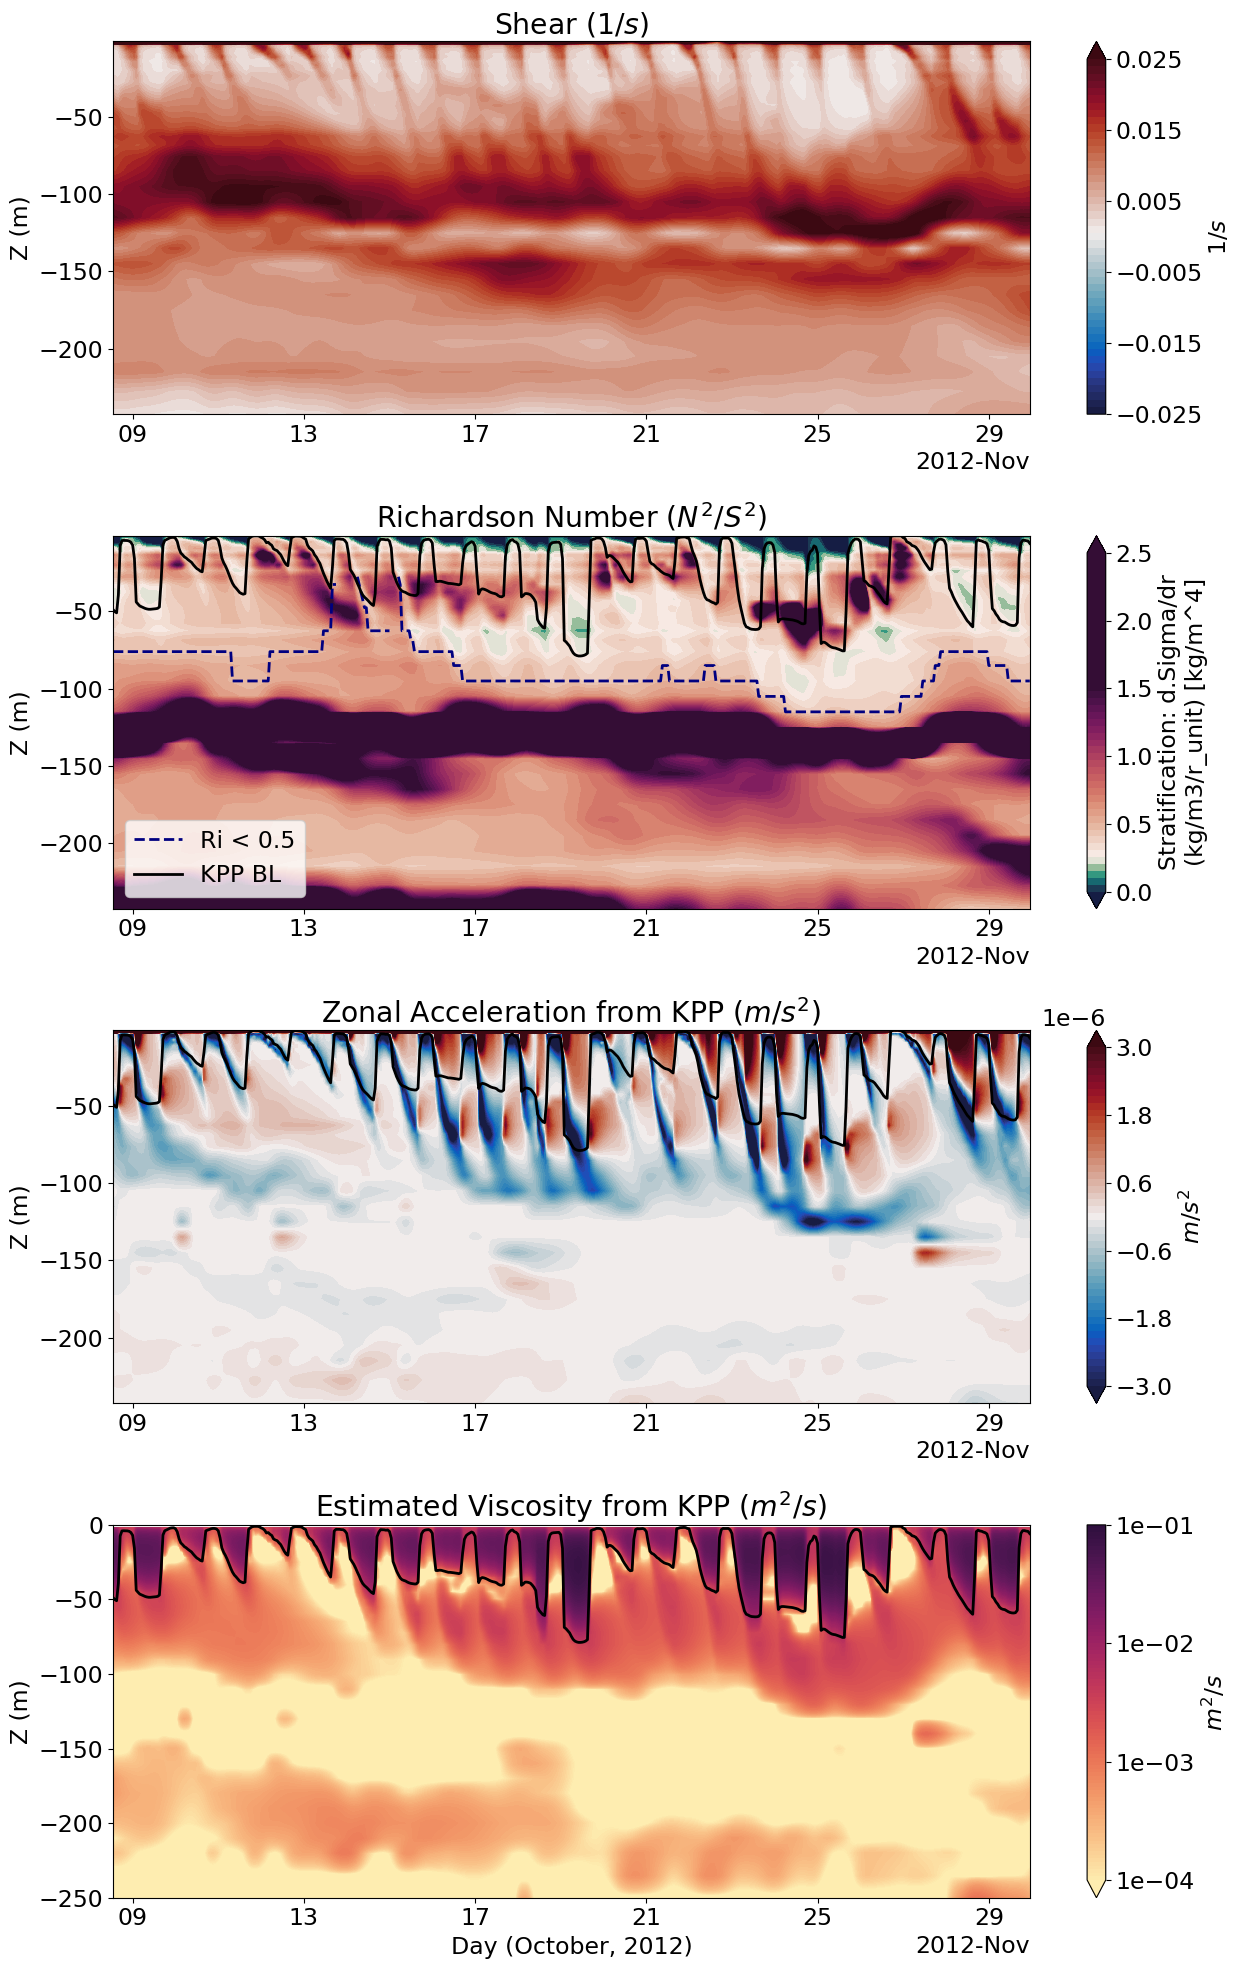

In [ ]:
from matplotlib.ticker import LogFormatter
fig, ax = plt.subplots(figsize=(13,20),nrows=4)
plot_hbl = -1*ds.KPPhbl.isel(time=slice(startDay,-1)).sel(YC=slice(-0.1,0.1)).sel(XC=[220.0],method='nearest').mean(dim='YC').squeeze().load()

levels = np.linspace(0,2.5,50)
ticks_Ri = np.linspace(0,2.5,6)
Ri.plot.contourf(ax=ax[1],x='time',y='Z',levels=levels,cmap=cmo.curl,norm=TwoSlopeNorm(vmin=0,vcenter=0.25,vmax=1.5),cbar_kwargs={'ticks':ticks_Ri})
ax[1].plot(Ri.time,deepest,color='navy',linewidth=2.0,linestyle='--',label='Ri < 0.5')
plot_hbl.plot(ax=ax[1],x='time',label='KPP BL',linewidth=2.0,color='k')
ax[1].set_ylabel('Z (m)')
ax[1].set_xlabel('')
ax[1].legend(loc='lower left')
ax[1].set_title('Richardson Number ($N^2/S^2$)')

levels = np.linspace(-0.025,0.025,50)
ticks_shear = np.linspace(-0.025,0.025,6)
plot_shear = shear.isel(time=slice(startDay,-1)).sel(Z=slice(zMax,zMin))
shear.plot.contourf(ax=ax[0],x='time',y='Z',levels=levels,cmap=cmo.balance,cbar_kwargs={'label':'$1/s$','ticks':ticks_shear},norm=TwoSlopeNorm(vmin=-0.025,vcenter=0,vmax=0.025))
ax[0].set_ylabel('Z (m)')
ax[0].set_xlabel('')
ax[0].set_title('Shear ($1/s$)')

levels = np.linspace(-3*(10**-6),3*(10**-6),50)
ticks_momU = np.linspace(-3*(10**-6),3*(10**-6),6)
plot_momU = ds.KPP_momU.isel(time=slice(startDay,-1)).sel(YC=slice(-0.1,0.1),Z=slice(zMax,zMin)).sel(XG=[220.0],method='nearest').mean(dim='YC').squeeze().load()
plot_momU.plot.contourf(ax=ax[2],x='time',y='Z',levels=levels,cmap=cmo.balance,cbar_kwargs={'label':'$m/s^2$','ticks':ticks_momU},norm=TwoSlopeNorm(vmin=-3*(10**-6),vcenter=0,vmax=3*(10**-6)))
plot_hbl.plot(ax=ax[2],x='time',label='KPP BL',linewidth=2.0,color='k')
ax[2].set_ylabel('Z (m)')
ax[2].set_xlabel('')
ax[2].set_title('Zonal Acceleration from KPP ($m/s^2$)')

levels = np.logspace(-4,-1,100)
ticks = [1e-4,1e-3,1e-2,1e-1]
plot_visc = ds.KPPviscA.isel(time=slice(startDay,-1)).sel(YC=slice(-0.1,0.1),Zl=slice(zMax,zMin)).sel(XC=[220.0],method='nearest').mean(dim='YC').squeeze().load()
plot_visc.plot.contourf(ax=ax[3],x='time',y='Zl',levels=levels,norm=LogNorm(vmin=1e-4,vmax=1e-1),cmap=cmo.matter,cbar_kwargs={'label':'$m^2/s$',"format": LogFormatter(),'ticks':ticks})
plot_hbl.plot(ax=ax[3],x='time',label='KPP BL',linewidth=2.0,color='k')
ax[3].set_ylabel('Z (m)')
ax[3].set_xlabel('Day (October, 2012)')
ax[3].set_title('Estimated Viscosity from KPP ($m^2/s$)')
plt.tight_layout()
image_str = 'Oct2012_Hourly_KPP_4panel_totalshear.png'
plt.savefig(image_str,format='png')

In [18]:
P1_x = [-0.0124, -0.0130, -0.0131, -0.0135, -0.0145, -0.0155, -0.0170, -0.0185, -0.0199, -0.0215, -0.0227, -0.0238, -0.0227, -0.0207, -0.0191, -0.0166, -0.0144, -0.0122, -0.0102, -0.00783, -0.00621, -0.00431, -0.00211, 0.0000943, 0.00171, 0.00333, 0.00509, 0.00597, 0.00730, 0.00745, 0.00790, 0.00893, 0.00968, 0.00954, 0.00896, 0.00795, 0.00825, 0.00900, 0.00974, 0.0102, 0.0101, 0.00933, 0.00787, 0.00627, 0.00496, 0.00424, 0.00337, 0.00294, 0.00295, 0.00253, 0.00254, 0.00299, 0.00314]
P1_y = [-27.8, -33.5, -39.2, -44.9, -51.7, -57.4, -61.5, -67.2, -72.6, -78.0, -82.7, -89.4, -93.5, -95.5, -97.9, -99.9, -102., -103., -105., -106., -108., -109., -110., -112., -113., -115., -118., -120., -123., -128., -134., -137., -143., -148., -152., -158., -164., -169., -176., -180., -184., -190., -194., -200., -204., -208., -214., -220., -225., -232., -238., -244., -248.]

P2_x = [-0.00754, -0.00783, -0.00738, -0.00796, -0.00883, -0.0103, -0.0113, -0.0117, -0.0114, -0.0111, -0.0107, -0.0114, -0.0129, -0.0148, -0.0166, -0.0184, -0.0197, -0.0207, -0.0207, -0.0197, -0.0178, -0.0151, -0.0125, -0.0101, -0.00736, -0.00457, -0.00207, -0.0000206, 0.00218, 0.00453, 0.00673, 0.00878, 0.0104, 0.0113, 0.0114, 0.00997, 0.00822, 0.00749, 0.00809, 0.00912, 0.0104, 0.0113, 0.0112, 0.0102, 0.00887, 0.00800, 0.00742, 0.00772, 0.00700, 0.00613, 0.00512, 0.00439, 0.00396, 0.00339, 0.00340, 0.00282, 0.00224, 0.00255, 0.00256]
P2_y = [-27.4, -31.8, -35.2, -39.9, -43.9, -49.3, -54.4, -59.8, -64.2, -69.6, -73.9, -79.3, -84.0, -87.8, -91.8, -96.5, -101., -105., -108., -112., -115., -118., -120., -122., -123., -126., -127., -128., -129., -130., -131., -133., -134., -136., -138., -141., -144., -149., -154., -159., -162., -166., -170., -174., -179., -183., -188., -193., -197., -201., -207., -212., -217., -222., -226., -231., -237., -242., -248.]

import numpy as np

# Define common y grid over overlapping range
y_min = max(min(P1_y), min(P2_y))
y_max = min(max(P1_y), max(P2_y))
y_common = np.linspace(y_min, y_max, 500)

# Average
x1_interp = np.interp(y_common, P1_y[::-1], P1_x[::-1])
x2_interp = np.interp(y_common, P2_y[::-1], P2_x[::-1])

x_avg = (x1_interp + x2_interp) / 2
x_avg = (x1_interp + x2_interp) / 2

In [15]:
len(x_avg)

500

In [26]:
shear_prof_plot = dUdz_XC.isel(time=slice(startDay,-1)).sel(YC=slice(-0.1,0.1),Z=slice(zMax,zMin)).sel(XC=[220.0],method='nearest').mean(dim=['YC','time']).load()
# shear_prof_std = dUdz_XC.isel(time=slice(startDay,-1)).sel(YC=slice(-0.1,0.1),Z=slice(zMax,zMin)).sel(XC=[220.0],method='nearest').mean(dim='YC').std(dim='time').load()

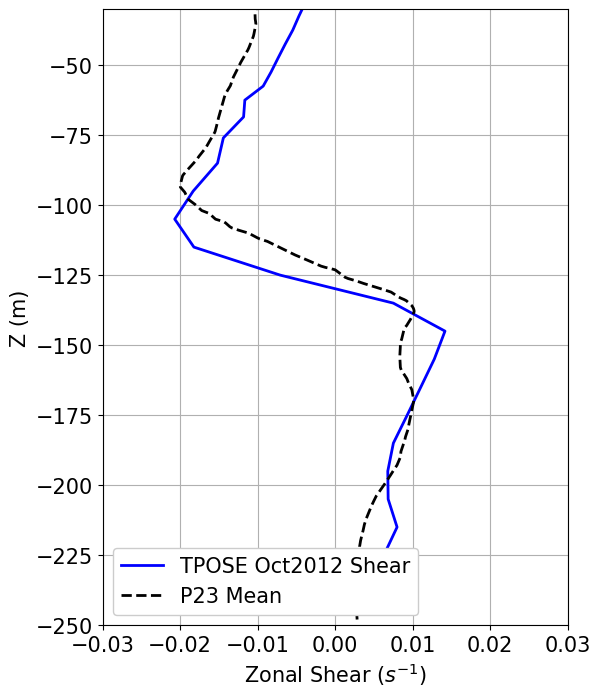

In [34]:
plt.rcParams['font.size'] = 15
fig, ax = plt.subplots(figsize=(6,8))
shear_prof_plot.plot(ax=ax,y='Z',color='b',linewidth=2.0,label='TPOSE Oct2012 Shear')
# ax.fill_betweenx(shear_prof_plot.Z, shear_prof_plot - shear_prof_std, shear_prof_plot + shear_prof_std, color='b', alpha=0.2)
ax.plot(x_avg,y_common,color='k',linestyle='--',linewidth=2.0,label='P23 Mean')
# ax.plot(P1_x,P1_y,color='k',linewidth=2.0,label='P23 Shear (Leg 1)')
# ax.plot(P2_x,P2_y,color='r',linewidth=2.0,label='P23 Shear (Leg 2)')
ax.set_xlim(-0.03,0.03)
ax.set_ylim(-30,-250)
# ax.axhline(-105)
# ax.axhline(-95)
ax.legend(loc='lower left',framealpha=1)
ax.grid()
ax.invert_yaxis()
ax.set_xlabel('Zonal Shear ($s^{-1}$)')
ax.set_ylabel('Z (m)')
ax.set_title('')
image_str = 'Oct2012_P23Shear_mean.png'
plt.savefig(image_str,format='png')

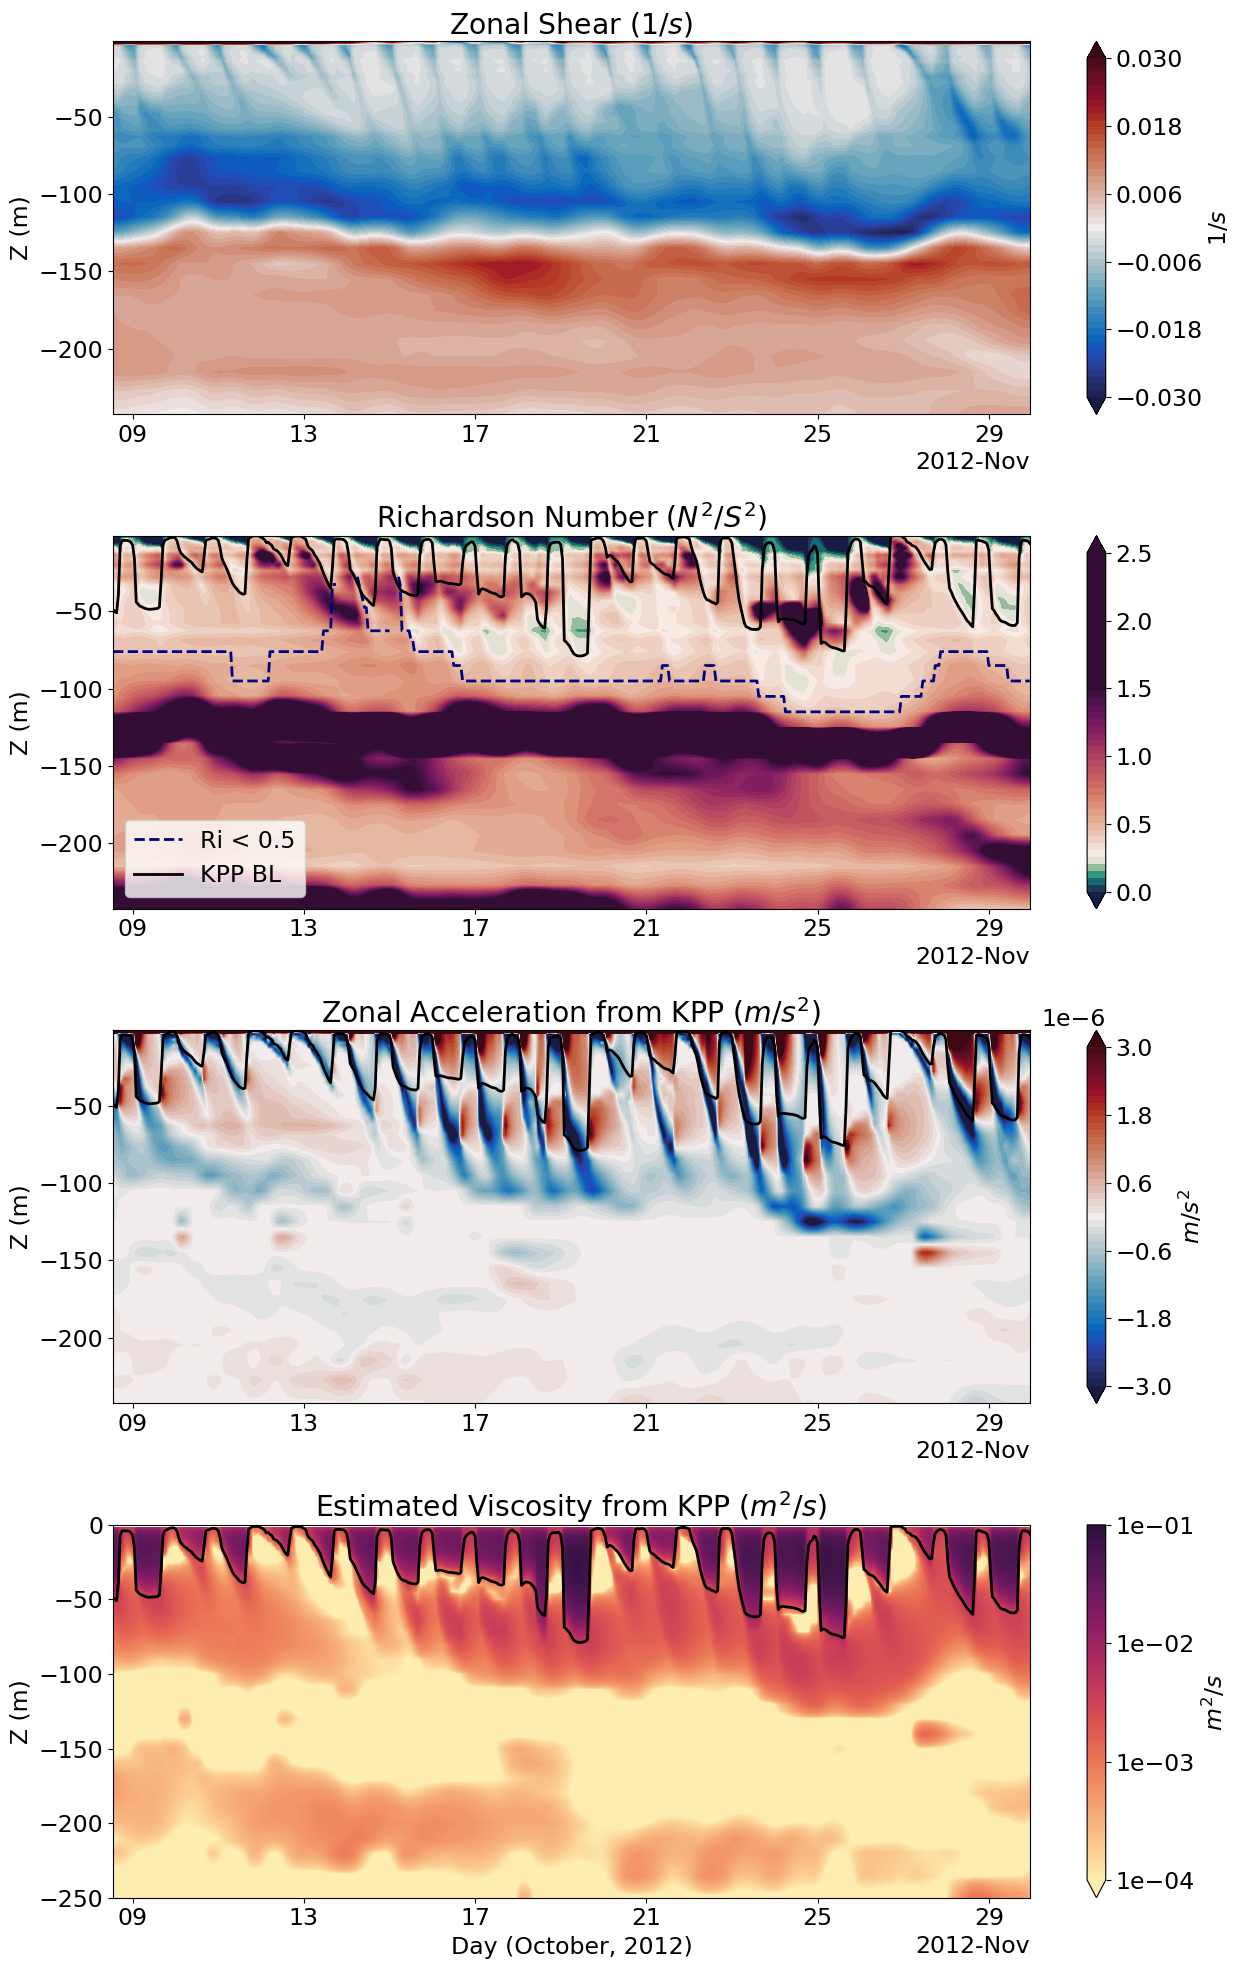

In [ ]:
from matplotlib.ticker import LogFormatter
fig, ax = plt.subplots(figsize=(13,20),nrows=4)
plot_hbl = -1*ds.KPPhbl.isel(time=slice(startDay,-1)).sel(YC=slice(-0.1,0.1)).sel(XC=[220.0],method='nearest').mean(dim='YC').squeeze().load()

levels = np.linspace(0,2.5,50)
ticks_Ri = np.linspace(0,2.5,6)
Ri.plot.contourf(ax=ax[1],x='time',y='Z',levels=levels,cmap=cmo.curl,norm=TwoSlopeNorm(vmin=0,vcenter=0.25,vmax=1.5),cbar_kwargs={'ticks':ticks_Ri})
ax[1].plot(Ri.time,deepest,color='navy',linewidth=2.0,linestyle='--',label='Ri < 0.5')
plot_hbl.plot(ax=ax[1],x='time',label='KPP BL',linewidth=2.0,color='k')
ax[1].set_ylabel('Z (m)')
ax[1].set_xlabel('')
ax[1].legend(loc='lower left')
ax[1].set_title('Richardson Number ($N^2/S^2$)')

levels = np.linspace(-0.03,0.03,50)
ticks_shear = np.linspace(-0.03,0.03,6)
plot_dUdz = dUdz_XC.isel(time=slice(startDay,-1)).sel(YC=slice(-0.1,0.1),Z=slice(zMax,zMin)).sel(XC=[220.0],method='nearest').mean(dim='YC').squeeze().load()
plot_dUdz.plot.contourf(ax=ax[0],x='time',y='Z',levels=levels,cmap=cmo.balance,cbar_kwargs={'label':'$1/s$','ticks':ticks_shear},norm=TwoSlopeNorm(vmin=-0.03,vcenter=0,vmax=0.03))
ax[0].set_ylabel('Z (m)')
ax[0].set_xlabel('')
ax[0].set_title('Zonal Shear ($1/s$)')

levels = np.linspace(-3*(10**-6),3*(10**-6),50)
ticks_momU = np.linspace(-3*(10**-6),3*(10**-6),6)
plot_momU = ds.KPP_momU.isel(time=slice(startDay,-1)).sel(YC=slice(-0.1,0.1),Z=slice(zMax,zMin)).sel(XG=[220.0],method='nearest').mean(dim='YC').squeeze().load()
plot_momU.plot.contourf(ax=ax[2],x='time',y='Z',levels=levels,cmap=cmo.balance,cbar_kwargs={'label':'$m/s^2$','ticks':ticks_momU},norm=TwoSlopeNorm(vmin=-3*(10**-6),vcenter=0,vmax=3*(10**-6)))
plot_hbl.plot(ax=ax[2],x='time',label='KPP BL',linewidth=2.0,color='k')
ax[2].set_ylabel('Z (m)')
ax[2].set_xlabel('')
ax[2].set_title('Zonal Acceleration from KPP ($m/s^2$)')

levels = np.logspace(-4,-1,100)
ticks = [1e-4,1e-3,1e-2,1e-1]
plot_visc = ds.KPPviscA.isel(time=slice(startDay,-1)).sel(YC=slice(-0.1,0.1),Zl=slice(zMax,zMin)).sel(XC=[220.0],method='nearest').mean(dim='YC').squeeze().load()
plot_visc.plot.contourf(ax=ax[3],x='time',y='Zl',levels=levels,norm=LogNorm(vmin=1e-4,vmax=1e-1),cmap=cmo.matter,cbar_kwargs={'label':'$m^2/s$',"format": LogFormatter(),'ticks':ticks})
plot_hbl.plot(ax=ax[3],x='time',label='KPP BL',linewidth=2.0,color='k')
ax[3].set_ylabel('Z (m)')
ax[3].set_xlabel('Day (October, 2012)')
ax[3].set_title('Estimated Viscosity from KPP ($m^2/s$)')
plt.tight_layout()
image_str = 'Oct2012_Hourly_KPP_4panel.png'
plt.savefig(image_str,format='png')